In [1]:
import mne
import openneuro
import pandas as pd
import numpy as np
np.set_printoptions(threshold=np.inf)
np.set_printoptions(linewidth=np.inf)
from mne_bids import (
    BIDSPath,
    find_matching_paths,
    get_entity_vals,
    make_report,
    print_dir_tree,
    read_raw_bids,
	write_raw_bids
)

In [61]:
def _channel_mapping(channel_list):
	new_list = []

	for channel in channel_list:
		if channel == "FP1":
			new_list.append("Fp1")
		elif channel == "FP2":
			new_list.append("Fp2")
		elif channel == "CZ":
			new_list.append("Cz")
		else:
			new_list.append(channel)
	return new_list


In [59]:
# From https://github.com/braindecode/braindecode/blob/master/braindecode/datasets/tuh.py
def _rename_channels(raw):
	"""
	Renames the EEG channels using mne conventions and sets their type to 'eeg'.

	See https://isip.piconepress.com/publications/reports/2020/tuh_eeg/electrodes/
	"""
	# remove ref suffix and prefix:
	# TODO: replace with removesuffix and removeprefix when 3.8 is dropped
	mapping_strip = {
		c: c.replace("-REF", "").replace("-LE", "").replace("EEG ", "")
		for c in raw.ch_names
	}
	raw.rename_channels(mapping_strip)

	montage1005 = mne.channels.make_standard_montage("standard_1005")
	mapping_eeg_names = {
		c.upper(): c for c in montage1005.ch_names if c.upper() in raw.ch_names
	}

	# Set channels whose type could not be inferred (defaulted to "eeg") to "misc":
	non_eeg_names = [c for c in raw.ch_names if c not in mapping_eeg_names]
	if non_eeg_names:
		non_eeg_types = raw.get_channel_types(picks=non_eeg_names)
		mapping_non_eeg_types = {
			c: "misc" for c, t in zip(non_eeg_names, non_eeg_types) if t == "eeg"
		}
		if mapping_non_eeg_types:
			raw.set_channel_types(mapping_non_eeg_types)

	if mapping_eeg_names:
		# Set 1005 channels type to "eeg":
		raw.set_channel_types(
			{c: "eeg" for c in mapping_eeg_names}, on_unit_change="ignore"
		)
		# Fix capitalized EEG channel names:
		raw.rename_channels(mapping_eeg_names)

In [3]:
openneuro.download(dataset="ds005505", target_dir="SampleData/HBN", include=["sub-NDARAC904DMU"])


👋 Hello! This is openneuro-py 2024.2.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds005505 …


📁 Traversing directories for ds005505 : 0 entities [00:00, ? entities/s]

📥 Retrieving up to 76 files (5 concurrent downloads). 
✅ Finished downloading ds005505.
 
🧠 Please enjoy your brains.
 


sub-NDARAC904DMU_task-DespicableMe_channels.tsv: 0.00B [00:00, ?B/s]

participants.tsv:   0%|          | 0.00/28.2k [00:00<?, ?B/s]

...

sub-NDARAC904DMU_task-symbolSearch_coordsystem.json:   0%|          | 0.00/97.0 [00:00<?, ?B/s]

sub-NDARAC904DMU_task-symbolSearch_eeg.set:   0%|          | 0.00/39.4M [00:00<?, ?B/s]

sub-NDARAC904DMU_task-symbolSearch_eeg.json:   0%|          | 0.00/231 [00:00<?, ?B/s]

sub-NDARAC904DMU_task-symbolSearch_electrodes.tsv:   0%|          | 0.00/4.11k [00:00<?, ?B/s]

sub-NDARAC904DMU_task-symbolSearch_events.tsv:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

In [62]:
TUH_patient = mne.io.read_raw_edf('SampleData/TUH/aaaaaaac_s001_t000.edf', preload=False)
_rename_channels(TUH_patient)
print(TUH_patient.info.ch_names)
TUH_patient.info["line_freq"] = 50
annotations_df = pd.read_csv('SampleData/TUH/aaaaaaac_s001_t000.csv', delimiter=',', comment='#')

onset = annotations_df['start_time']
duration = annotations_df['stop_time'] - annotations_df['start_time']
description = annotations_df['label']
ch_names = [_channel_mapping(x.split("-")) for x in annotations_df['channel'].values.tolist()]

global_annotations_df = pd.read_csv('SampleData/TUH/aaaaaaac_s001_t000.csv_bi', delimiter=',', comment='#')

onset = pd.concat([onset, global_annotations_df['start_time']])
duration = pd.concat([duration, global_annotations_df['stop_time'] - global_annotations_df['start_time']])
description = pd.concat([description, global_annotations_df['label']])
global_channel_names = [[] for x in global_annotations_df['channel'].values.tolist()]
ch_names = ch_names + global_channel_names

annotations = mne.Annotations(onset=onset, duration=duration, description=description, ch_names=ch_names)

TUH_patient.set_annotations(annotations)
montage = mne.channels.make_standard_montage("standard_1005")
TUH_patient.set_montage(montage, on_missing="ignore")
for channel in TUH_patient.info["chs"]:
	print(channel['loc'])

Extracting EDF parameters from /storage/ice1/1/9/mchen439/EEG-Foundation-Model/SampleData/TUH/aaaaaaac_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'A1', 'A2', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz', 'Oz', 'PG1', 'PG2', 'EKG', 'SP2', 'SP1', 'RLC', 'LUC', '30', 'T1', 'T2', 'PHOTIC PH']
[-0.03090259  0.11458518  0.02786657  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[0.0284095  0.11534631 0.02772126 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.05180904  0.0866879   0.07871409  0.          0.          0.                 nan         nan         nan         nan         nan         nan]
[0.05027428 0.08743839 0.07727065 0.         0.         0.                nan        nan        nan        nan        nan        nan]
[-0.06714872  0.023358

/tmp/ipykernel_30104/1918410036.py:29: RuntimeWarning: The unit for channel(s) 30, EKG, LUC, PG1, PG2, PHOTIC PH, RLC, SP1, SP2, T1, T2 has changed from V to NA.
  raw.set_channel_types(mapping_non_eeg_types)


In [29]:
bids_path = BIDSPath(subject="aaaaaaac", task="Rest", root="SampleData/TUH-BIDS")
write_raw_bids(TUH_patient, bids_path, overwrite=True)

Extracting EDF parameters from /storage/ice1/1/9/mchen439/EEG-Foundation-Model/SampleData/TUH/aaaaaaac_s001_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Writing 'SampleData/TUH-BIDS/participants.tsv'...
Writing 'SampleData/TUH-BIDS/participants.json'...
Writing 'SampleData/TUH-BIDS/sub-aaaaaaac/eeg/sub-aaaaaaac_space-CapTrak_electrodes.tsv'...
Writing 'SampleData/TUH-BIDS/sub-aaaaaaac/eeg/sub-aaaaaaac_space-CapTrak_coordsystem.json'...
The provided raw data contains annotations, but you did not pass an "event_id" mapping from annotation descriptions to event codes. We will generate arbitrary event codes. To specify custom event codes, please pass "event_id".
Used Annotations descriptions: ['bckg', 'cpsz']
Writing 'SampleData/TUH-BIDS/sub-aaaaaaac/eeg/sub-aaaaaaac_task-Rest_events.tsv'...
Writing 'SampleData/TUH-BIDS/sub-aaaaaaac/eeg/sub-aaaaaaac_task-Rest_events.json'...
Writing 'SampleData/TUH-BIDS/dataset_description.json'...
Writing 

BIDSPath(
root: SampleData/TUH-BIDS
datatype: eeg
basename: sub-aaaaaaac_task-Rest_eeg.edf)

In [7]:
hbn_bids_path = BIDSPath(root="SampleData/HBN", session=None, datatype="eeg")
hbn_bids_path = hbn_bids_path.update(subject="NDARAC904DMU", task="RestingState", suffix="eeg")
HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)

/tmp/ipykernel_30104/2368780825.py:3: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)


Reading events from SampleData/HBN/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_events.tsv.
Reading channel info from SampleData/HBN/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_channels.tsv.
Reading electrode coords from SampleData/HBN/sub-NDARAC904DMU/eeg/sub-NDARAC904DMU_task-RestingState_electrodes.tsv.


/tmp/ipykernel_30104/2368780825.py:3: RuntimeWarning: Unable to map the following column(s) to to MNE:
release_number: R1
ehq_total: 71.17
commercial_use: Yes
full_pheno: Yes
p_factor: -0.603
attention: -0.446
internalizing: 1.248
externalizing: 0.325
RestingState: available
DespicableMe: available
FunwithFractals: available
ThePresent: available
DiaryOfAWimpyKid: available
contrastChangeDetection_1: available
contrastChangeDetection_2: available
contrastChangeDetection_3: available
surroundSupp_1: available
surroundSupp_2: available
seqLearning6target: unavailable
seqLearning8target: available
symbolSearch: available
  HBN_patient = read_raw_bids(bids_path=hbn_bids_path, verbose=True)


In [8]:
tuh_bids_path = BIDSPath(root="SampleData/TUH-BIDS", session=None, datatype="eeg")
tuh_bids_path = tuh_bids_path.update(subject="aaaaaaac", task="Rest", suffix="eeg")
TUH_patient = read_raw_bids(bids_path=tuh_bids_path, verbose=True)

Extracting EDF parameters from /storage/ice1/1/9/mchen439/EEG-Foundation-Model/SampleData/TUH-BIDS/sub-aaaaaaac/eeg/sub-aaaaaaac_task-Rest_eeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading channel info from SampleData/TUH-BIDS/sub-aaaaaaac/eeg/sub-aaaaaaac_task-Rest_channels.tsv.
Reading electrode coords from SampleData/TUH-BIDS/sub-aaaaaaac/eeg/sub-aaaaaaac_space-CapTrak_electrodes.tsv.
Not fully anonymizing info - keeping his_id, sex, and hand info


/tmp/ipykernel_30104/3753720600.py:3: RuntimeWarning: Did not find any events.tsv associated with sub-aaaaaaac_task-Rest.

The search_str was "SampleData/TUH-BIDS/sub-aaaaaaac/**/eeg/sub-aaaaaaac*events.tsv"
  TUH_patient = read_raw_bids(bids_path=tuh_bids_path, verbose=True)
/tmp/ipykernel_30104/3753720600.py:3: RuntimeWarning: There are channels without locations (n/a) that are not marked as bad: ['PG1', 'PG2', 'EKG', 'SP2', 'SP1', 'RLC', 'LUC', '30', 'T1', 'T2', 'PHOTIC PH']
  TUH_patient = read_raw_bids(bids_path=tuh_bids_path, verbose=True)
/tmp/ipykernel_30104/3753720600.py:3: RuntimeWarning: Not setting positions of 11 misc channels found in montage:
['PG1', 'PG2', 'EKG', 'SP2', 'SP1', 'RLC', 'LUC', '30', 'T1', 'T2', 'PHOTIC PH']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  TUH_patient = read_raw_bids(bids_path=tuh_bids_path, verbose=True)


In [9]:
TUH_patient.load_data()
TUH_patient.set_eeg_reference(ref_channels=['A1', 'A2'])
print(TUH_patient.info)
TUH_patient.set_eeg_reference(ref_channels=['Cz'])

Reading 0 ... 75249  =      0.000 ...   300.996 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
<Info | 13 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, A1, A2, P3, P4, O1, O2, F7, F8, T3, ...
 chs: 22 EEG, 11 misc
 custom_ref_applied: True
 description: Anonymized using a time shift to preserve age at acquisition
 dig: 25 items (3 Cardinal, 22 EEG)
 experimenter: mne_anonymize
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 125.0 Hz
 meas_date: 2002-01-01 00:00:00 UTC
 nchan: 33
 projs: []
 sfreq: 250.0 Hz
 subject_info: 3 items (dict)
>
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


<RawEDF | sub-aaaaaaac_task-Rest_eeg.edf, 33 x 75250 (301.0 s), ~19.0 MB, data loaded>

In [10]:
# See Page 234 of /https://psych.colgate.edu/~bchansen/EGI_GES_INFO/NetStation_Acquisition_Technical_Manual.pdf
electrode_map = {
	'Fp1': 'E22',
	'Fp2': 'E14',
	'F7': 'E34',
	'F3': 'E25',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E46',
	'C3': 'E37',
	'Cz': 'Cz',
	'C4': 'E105',
	'T4': 'E109',
	'T5': 'E59',
	'P3': 'E53',
	'Pz': 'E62',
	'P4': 'E87',
	'T6': 'E92',
	'O1': 'E72',
	'O2': 'E77',
	'A1': 'E49',
	'A2': 'E114'
}

electrode_map2 = {
	'Fp1': 'E22',
	'Fp2': 'E9',
	'F7': 'E33',
	'F3': 'E24',
	'Fz': 'E11',
	'F4': 'E124',
	'F8': 'E122',
	'T3': 'E45',
	'C3': 'E36',
	'Cz': 'Cz',
	'C4': 'E104',
	'T4': 'E108',
	'T5': 'E58',
	'P3': 'E52',
	'Pz': 'E62',
	'P4': 'E92',
	'T6': 'E96',
	'O1': 'E70',
	'O2': 'E83',
	'A1': 'E49',
	'A2': 'E113'
}

electrodes = [f'E{i}' for i in range(1, 129)]
to_drop = [electrode for electrode in electrodes if electrode not in electrode_map2.values()]

In [11]:
TUH_patient = TUH_patient.filter(l_freq=0, h_freq=40)
HBN_patient.drop_channels(to_drop)
HBN_patient = HBN_patient.filter(l_freq=0, h_freq=40)

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 83 samples (0.332 s)

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 165 samples (0.330 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


In [12]:
TUH_patient.info

<Info | 13 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, A1, A2, P3, P4, O1, O2, F7, F8, T3, ...
 chs: 22 EEG, 11 misc
 custom_ref_applied: True
 description: Anonymized using a time shift to preserve age at acquisition
 dig: 25 items (3 Cardinal, 22 EEG)
 experimenter: mne_anonymize
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 40.0 Hz
 meas_date: 2002-01-01 00:00:00 UTC
 nchan: 33
 projs: []
 sfreq: 250.0 Hz
 subject_info: 3 items (dict)
>

In [13]:
HBN_patient.info

<Info | 10 non-empty values
 bads: []
 ch_names: E9, E11, E22, E24, E33, E36, E45, E49, E52, E58, E62, E70, E83, ...
 chs: 21 EEG
 custom_ref_applied: False
 dig: 129 items (129 EEG)
 highpass: 0.0 Hz
 line_freq: 60.0
 lowpass: 40.0 Hz
 meas_date: unspecified
 nchan: 21
 projs: []
 sfreq: 500.0 Hz
 subject_info: 2 items (dict)
>

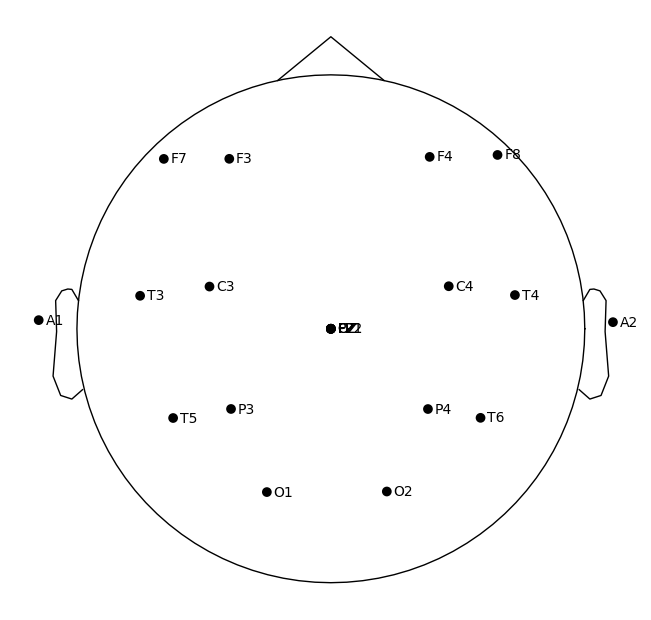

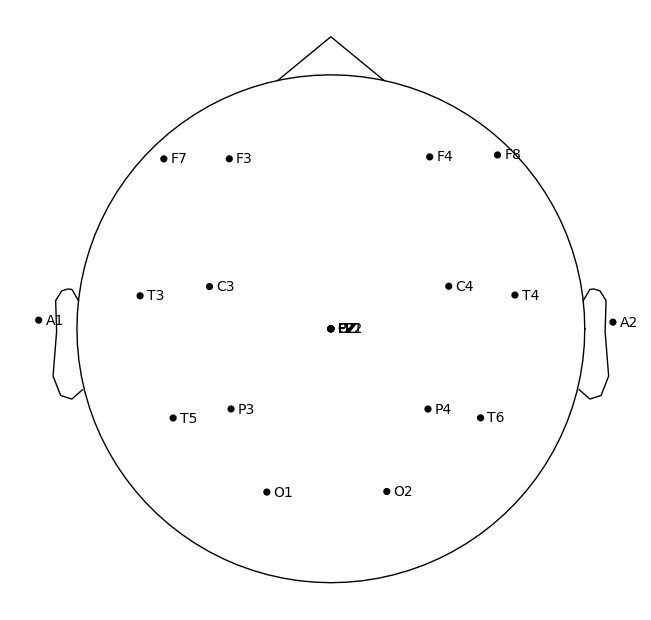

In [57]:
TUH_patient.get_montage().plot(show_names=True)

In [15]:
for channel in HBN_patient.info["chs"]:
	print(channel)

{'loc': array([ 0.00888482, -0.00269541,  0.00108831,  0.        ,  0.        ,  0.        ,         nan,         nan,         nan,         nan,         nan,         nan]), 'unit_mul': 0 (FIFF_UNITM_NONE), 'range': 1.0, 'cal': 1e-06, 'kind': 2 (FIFFV_EEG_CH), 'coil_type': 1 (FIFFV_COIL_EEG), 'unit': 107 (FIFF_UNIT_V), 'coord_frame': 4 (FIFFV_COORD_HEAD), 'ch_name': 'E9', 'scanno': 9, 'logno': 9}
{'loc': array([ 0.00796265, -0.        ,  0.00504472,  0.        ,  0.        ,  0.        ,         nan,         nan,         nan,         nan,         nan,         nan]), 'unit_mul': 0 (FIFF_UNITM_NONE), 'range': 1.0, 'cal': 1e-06, 'kind': 2 (FIFFV_EEG_CH), 'coil_type': 1 (FIFFV_COIL_EEG), 'unit': 107 (FIFF_UNIT_V), 'coord_frame': 4 (FIFFV_COORD_HEAD), 'ch_name': 'E11', 'scanno': 11, 'logno': 11}
{'loc': array([0.00888482, 0.00269541, 0.00108831, 0.        , 0.        , 0.        ,        nan,        nan,        nan,        nan,        nan,        nan]), 'unit_mul': 0 (FIFF_UNITM_NONE), 'rang

/tmp/ipykernel_30104/3267157450.py:4: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  hbn_montage.plot(show_names=True, sphere=0.0095)


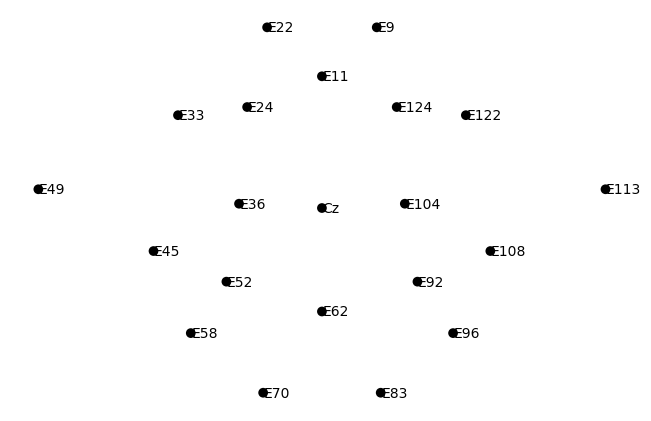

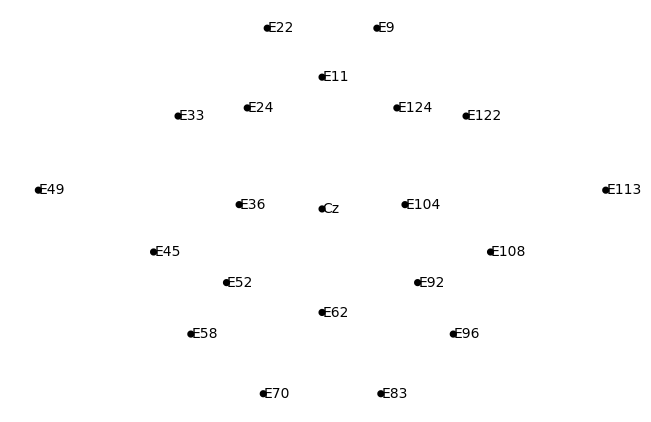

In [16]:
transformation_matrix = np.asarray([[0, -100, 0, 0], [100, 0, 0, 0], [0, 0, 100, 0], [0, 0, 0, 100]])
hbn_montage = HBN_patient.get_montage()
hbn_montage.apply_trans(mne.transforms.Transform(fro='ctf_head', to='unknown', trans=transformation_matrix))
hbn_montage.plot(show_names=True, sphere=0.0095)

Using matplotlib as 2D backend.


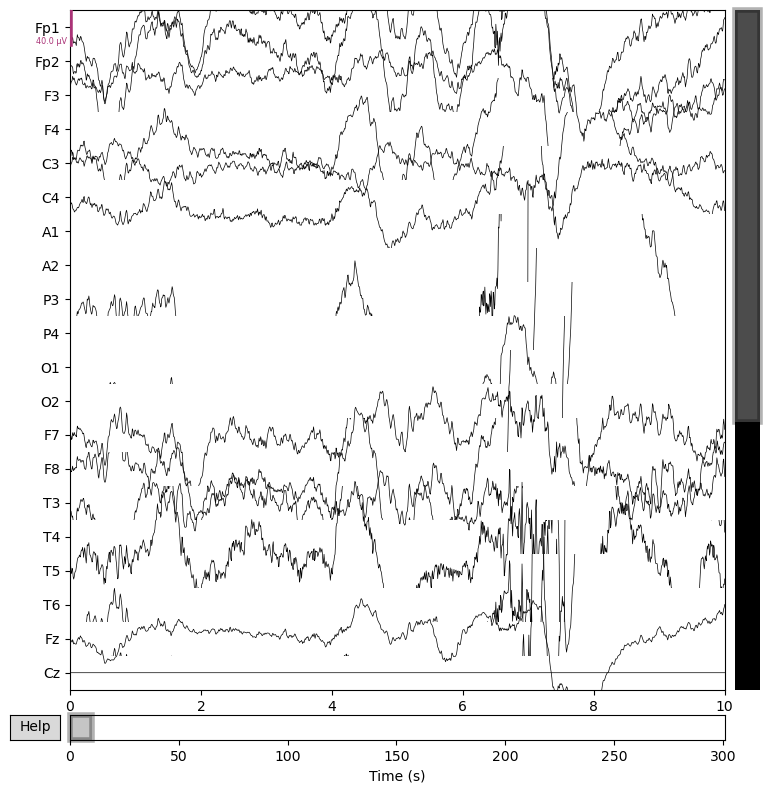

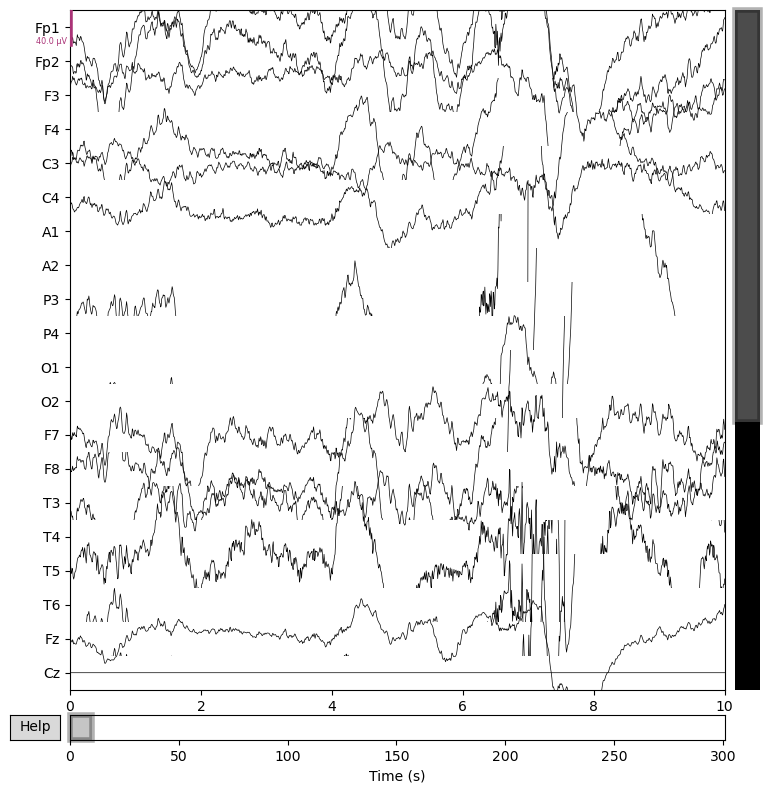

In [17]:
mne.viz.set_browser_backend("matplotlib")
TUH_patient.plot()

In [56]:
print(TUH_patient.annotations)

<Annotations | 67 segments, channel-specific: bckg (44), cpsz (22), seiz (1)>
